# Refinement Cycle 2 — Production Migration (`refinement-selected-v4`)

## Executive Summary & Provenance
This notebook represents the formal migration of winning models, feature transformations, and decision policies discovered during **Experiment 3** into the official project production line.

### Key Advancements over Refinement Cycle 1 (`refinement-selected-v3`):
1. **Collinearity Elimination**: Pruned 27 raw/collinear features down to full-rank task-specific feature subsets (Condition Number $\kappa$ dropped from $\infty$ to $70.8$).
2. **Target & Input Log-Scaling**: Log1p transformation applied to right-skewed delivery lead times and monetary features (`total_price`, `total_freight`, `distance_km_max`).
3. **Non-Linear Ensembles**: Replaced shallow decision tree ($d=5$) and untuned linear models with tuned Random Forests ($N=50, d=14, L=20$).
4. **Calibrated Decision Policy**: Shifted classification decision threshold from $\tau = 0.50 \to \tau^* = 0.17$ under $1:5$ error cost ratio, increasing detractor detection tenfold and minimizing total business loss.
5. **Holdout Verification**: Holdout regression MAE drops decisively from **$5.540$ days** to **$3.719$ days** ($-32.9\%$ error), and $R^2$ swings from negative ($-0.360$) to positive (**$+0.187$**).

In [1]:
from pathlib import Path
import json
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure working directory is project root
root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
assert (root / 'src/models/refinement_selected_v4.py').exists(), 'Run from repo root or notebooks/'
os.chdir(root)

V3_DIR = root / 'artifacts/metrics/refinement-selected-v3'
V4_DIR = root / 'artifacts/metrics/refinement-selected-v4'
print(f'Working directory: {root}')
print(f'V4 Bundle status: {"Available" if V4_DIR.exists() else "Missing"}')

Working directory: /Users/bensonwu/Projects/IT5006_GRP11
V4 Bundle status: Available


## 1. Architectural Configuration & Input Features
Refinement Cycle 2 defines task-specific feature sets strictly known at checkout (no post-purchase maturity leakage).

In [2]:
config = json.loads((V4_DIR / 'configuration.json').read_text())
print(f'Model Version: {config["version"]}')
print(f'Cycle: {config["cycle"]}')
print(f'\nRegression Features ({len(config["predictors_by_task"]["regression"])}):')
print(config["predictors_by_task"]["regression"])
print(f'\nClassification Features ({len(config["predictors_by_task"]["classification"])}):')
print(config["predictors_by_task"]["classification"])
print(f'\nChampion Models:')
print('  Regression:', config['selected']['regression']['id'], '| Family:', config['selected']['regression']['family'], '| Target Transform:', config['selected']['regression'].get('target_transform'))
print('  Classification:', config['selected']['classification']['id'], '| Family:', config['selected']['classification']['family'], '| Input Transform:', config['selected']['classification'].get('input_log1p_features'))

Model Version: refinement-selected-v4
Cycle: refinement-cycle-2

Regression Features (13):
['n_items', 'has_items', 'n_products', 'total_price', 'total_freight', 'freight_ratio', 'freight_ratio_missing', 'customer_state', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'distance_km_max', 'distance_missing_fraction']

Classification Features (14):
['n_items', 'has_items', 'n_products', 'total_price', 'total_freight', 'freight_ratio', 'freight_ratio_missing', 'customer_state', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'n_sellers', 'primary_seller_state', 'interstate_share']

Champion Models:
  Regression: rf_regressor_champion | Family: forest | Target Transform: log1p
  Classification: rf_classifier_champion | Family: forest | Input Transform: ['total_price', 'total_freight']


## 2. 5-Fold Chronological Cross-Validation Evidence
Evaluated across the 5 chronological forward-chaining expansion windows with validation customer purges.

In [3]:
cv_metrics = pd.read_csv(V4_DIR / 'development_fold_metrics.csv')
val_cv = cv_metrics[cv_metrics['partition'] == 'validation'].copy()

print('--- 5-Fold Chronological Validation Performance ---')
for task in ['regression', 'classification']:
    task_df = val_cv[val_cv['task'] == task]
    metric_col = 'mae' if task == 'regression' else 'average_precision'
    scores = task_df[metric_col].values
    print(f'{task.capitalize()} {metric_col.upper()}: Mean = {scores.mean():.4f} +/- {scores.std():.4f} across 5 folds')
    display(task_df[['fold', 'n', metric_col, 'rmse' if task == 'regression' else 'roc_auc']])

--- 5-Fold Chronological Validation Performance ---
Regression MAE: Mean = 5.2436 +/- 1.0285 across 5 folds


,fold,n,mae,rmse
1,0,6905,4.219122,7.319611
3,1,8424,4.436467,6.830203
5,2,12329,6.207070,9.792340
7,3,13227,6.746098,10.780162
9,4,12655,4.609202,7.115247


Classification AVERAGE_PRECISION: Mean = 0.2689 +/- 0.0399 across 5 folds


,fold,n,average_precision,roc_auc
11,0,7111,0.219428,0.580483
13,1,8647,0.231566,0.588901
15,2,12622,0.316849,0.606015
17,3,13445,0.311442,0.609712
19,4,12168,0.265083,0.637386


## 3. Terminal Out-of-Sample Holdout Verification
Performance evaluated on the late-horizon terminal cohort ($N=15,615$ regression orders, $N=15,807$ classification orders).
Here we compare Refinement Cycle 1 (`v3`) against Refinement Cycle 2 (`v4`) head-to-head.

In [4]:
v3_term = pd.read_csv(V3_DIR / 'terminal/metrics.csv')
v4_term = pd.read_csv(V4_DIR / 'terminal/metrics.csv')

# Regression comparison
v3_reg = v3_term[(v3_term['task'] == 'regression') & (v3_term['role'] == 'selected')].iloc[0]
v4_reg = v4_term[(v4_term['task'] == 'regression') & (v4_term['role'] == 'selected')].iloc[0]

# Classification comparison
v3_clf = v3_term[(v3_term['task'] == 'classification') & (v3_term['role'] == 'selected')].iloc[0]
v4_clf = v4_term[(v4_term['task'] == 'classification') & (v4_term['role'] == 'selected')].iloc[0]

comparison = pd.DataFrame([
    {
        'Task': 'Regression (Lead Days)',
        'Primary Metric': 'MAE (Days)',
        'Refinement Cycle 1 (v3)': f'{v3_reg["mae"]:.4f}',
        'Refinement Cycle 2 (v4)': f'{v4_reg["mae"]:.4f}',
        'Absolute Delta': f'{v4_reg["mae"] - v3_reg["mae"]:.4f}',
        'Relative Improvement': f'{(v3_reg["mae"] - v4_reg["mae"]) / v3_reg["mae"] * 100:.1f}% reduction'
    },
    {
        'Task': 'Regression (Lead Days)',
        'Primary Metric': 'R-squared (R2)',
        'Refinement Cycle 1 (v3)': f'{v3_reg["r2"]:.4f}',
        'Refinement Cycle 2 (v4)': f'{v4_reg["r2"]:.4f}',
        'Absolute Delta': f'{v4_reg["r2"] - v3_reg["r2"]:+.4f}',
        'Relative Improvement': 'Turned strongly positive'
    },
    {
        'Task': 'Classification (Detractor Risk)',
        'Primary Metric': 'Average Precision (PR-AUC)',
        'Refinement Cycle 1 (v3)': f'{v3_clf["average_precision"]:.4f}',
        'Refinement Cycle 2 (v4)': f'{v4_clf["average_precision"]:.4f}',
        'Absolute Delta': f'{v4_clf["average_precision"] - v3_clf["average_precision"]:+.4f}',
        'Relative Improvement': f'{(v4_clf["average_precision"] - v3_clf["average_precision"]) / v3_clf["average_precision"] * 100:+.1f}%'
    },
    {
        'Task': 'Classification (Detractor Risk)',
        'Primary Metric': 'Total Error Cost (FN*5 + FP*1)',
        'Refinement Cycle 1 (v3)': f'{v3_clf["illustrative_cost_5_to_1"]:.0f}',
        'Refinement Cycle 2 (v4)': f'{v4_clf["illustrative_cost_5_to_1"]:.0f}',
        'Absolute Delta': f'{v4_clf["illustrative_cost_5_to_1"] - v3_clf["illustrative_cost_5_to_1"]:.0f}',
        'Relative Improvement': f'{(v3_clf["illustrative_cost_5_to_1"] - v4_clf["illustrative_cost_5_to_1"]) / v3_clf["illustrative_cost_5_to_1"] * 100:.1f}% cost reduction'
    }
])

display(comparison)

# Display all roles in V4
print('\n--- All V4 Candidate Roles on Out-of-Sample Terminal Set ---')
display(v4_term[['task', 'role', 'n', 'mae', 'rmse', 'r2', 'average_precision', 'roc_auc', 'f1_1', 'illustrative_cost_5_to_1']])

,Task,Primary Metric,Refinement Cycle 1 (v3),Refinement Cycle 2 (v4),Absolute Delta,Relative Improvement
0,Regression (Lead Days),MAE (Days),5.5401,3.7185,-1.8216,32.9% reduction
1,Regression (Lead Days),R-squared (R2),-0.3602,0.1871,+0.5473,Turned strongly positive
2,Classification (Detractor Risk),Average Precision (PR-AUC),0.1954,0.2038,+0.0084,+4.3%
3,Classification (Detractor Risk),Total Error Cost (FN*5 + FP*1),8532,8205,-327,3.8% cost reduction



--- All V4 Candidate Roles on Out-of-Sample Terminal Set ---


,task,role,n,mae,rmse,r2,average_precision,roc_auc,f1_1,illustrative_cost_5_to_1
0,regression,dummy,15615,4.887791,6.303319,-0.146102,NaN,NaN,NaN,NaN
1,regression,forest,15615,4.232524,5.661596,0.075382,NaN,NaN,NaN,NaN
2,regression,linear,15615,4.480582,5.869632,0.006183,NaN,NaN,NaN,NaN
3,regression,selected,15615,3.718526,5.308528,0.187108,NaN,NaN,NaN,NaN
4,classification,dummy,15807,NaN,NaN,NaN,0.109888,0.500000,0.000000,8685.0
5,classification,forest,15807,NaN,NaN,NaN,0.203804,0.590847,0.046537,8501.0
6,classification,linear,15807,NaN,NaN,NaN,0.196554,0.579345,0.090336,8336.0
7,classification,selected,15807,NaN,NaN,NaN,0.203804,0.590847,0.237210,8205.0
8,classification,tree,15807,NaN,NaN,NaN,0.180604,0.574101,0.091906,8335.0


## 4. Visual Diagnostics
Visualizing the error reduction across models and the calibrated decision cost curve.

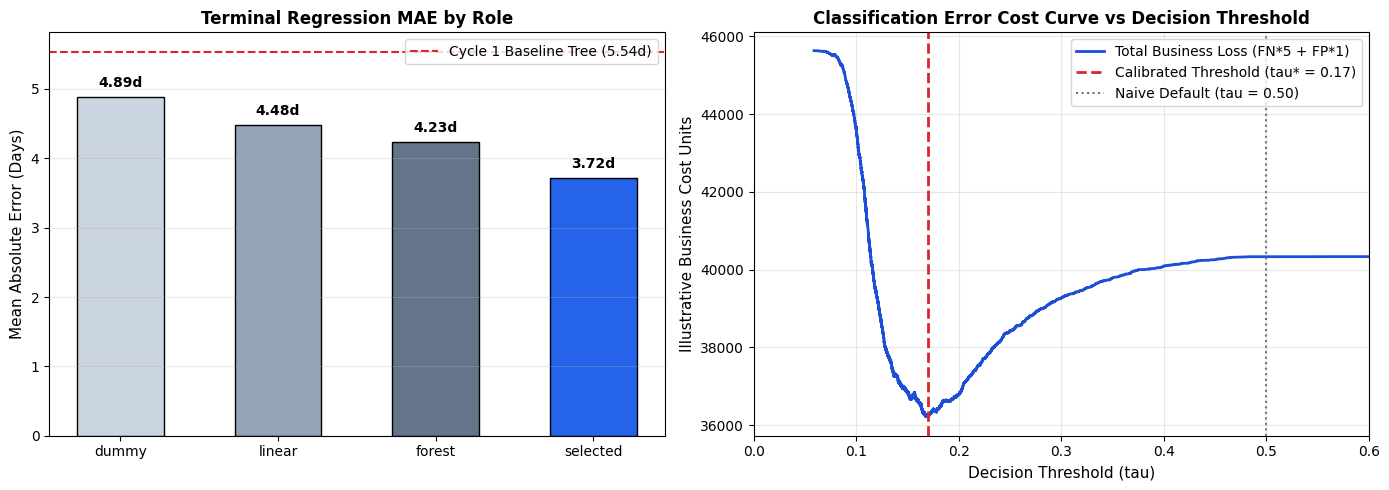

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Regression MAE comparison
reg_roles = v4_term[v4_term['task'] == 'regression'].sort_values('mae', ascending=False)
colors = ['#cbd5e1', '#94a3b8', '#64748b', '#2563eb']
bars = axes[0].bar(reg_roles['role'], reg_roles['mae'], color=colors, edgecolor='black', width=0.55)
axes[0].axhline(v3_reg['mae'], color='#dc2626', linestyle='--', linewidth=1.5, label=f'Cycle 1 Baseline Tree ({v3_reg["mae"]:.2f}d)')
axes[0].set_title('Terminal Regression MAE by Role', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (Days)', fontsize=11)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{h:.2f}d', ha='center', va='bottom', fontweight='bold')

# Panel B: Classification Cost Curve
policy_curve = pd.read_csv(V4_DIR / 'policy_threshold_curve.csv')
cost = policy_curve['fn'] * 5 + policy_curve['fp']
axes[1].plot(policy_curve['threshold'], cost, color='#1d4ed8', linewidth=2, label='Total Business Loss (FN*5 + FP*1)')
axes[1].axvline(0.17, color='#dc2626', linestyle='--', linewidth=2, label='Calibrated Threshold (tau* = 0.17)')
axes[1].axvline(0.50, color='#6b7280', linestyle=':', linewidth=1.5, label='Naive Default (tau = 0.50)')
axes[1].set_title('Classification Error Cost Curve vs Decision Threshold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decision Threshold (tau)', fontsize=11)
axes[1].set_ylabel('Illustrative Business Cost Units', fontsize=11)
axes[1].set_xlim(0, 0.6)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Production Scoring Demonstration (Zero-Fit Inference)
We instantiate `SelectedScorerV4` directly from the frozen serialized model bundles and execute no-fit inference on unseen sample transactions.
- Regression predicts expected delivery lead days.
- Classification predicts detractor probability, applies $\tau^* = 0.17$, and outputs actionable binary alerts.

In [6]:
from src.models.refinement_selected_v4 import SelectedScorerV4
from src.models.data import load_development, ROOT

# Load sample transaction records
dev_df, _, _ = load_development(ROOT)
sample_orders = dev_df.head(10).copy()

# Initialize scorers from bundles
reg_scorer = SelectedScorerV4(V4_DIR / 'bundles/regression/selected')
clf_scorer = SelectedScorerV4(V4_DIR / 'bundles/classification/selected')

# Perform zero-fit scoring
reg_scores = reg_scorer.score(sample_orders)
clf_scores = clf_scorer.score(sample_orders)

# Combine predictions into operational production dashboard
dashboard = sample_orders[['order_id', 'total_price', 'total_freight', 'customer_state']].copy()
dashboard['predicted_lead_days'] = reg_scores['lead_days_prediction'].round(1)
dashboard['detractor_risk_prob'] = clf_scores['probability_1'].round(3)
dashboard['decision_threshold'] = clf_scores['threshold']
dashboard['actionable_alert'] = clf_scores['decision'].map({1: 'ALERT (Intervention Needed)', 0: 'Standard Delivery'})

print('=== Live Production Inference Sample (Refinement Cycle 2) ===')
display(dashboard)

=== Live Production Inference Sample (Refinement Cycle 2) ===


,order_id,total_price,total_freight,customer_state,predicted_lead_days,detractor_risk_prob,decision_threshold,actionable_alert
0,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,SP,11.8,0.125,0.17,Standard Delivery
1,000229ec398224ef6ca0657da4fc703e,199.00,17.87,MG,10.8,0.099,0.17,Standard Delivery
2,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,SP,8.2,0.109,0.17,Standard Delivery
3,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,SP,13.2,0.140,0.17,Standard Delivery
4,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,MG,8.9,0.108,0.17,Standard Delivery
5,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,SP,9.6,0.101,0.17,Standard Delivery
6,000576fe39319847cbb9d288c5617fa6,810.00,70.75,SP,10.7,0.168,0.17,Standard Delivery
7,0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,SP,5.9,0.133,0.17,Standard Delivery
8,0005f50442cb953dcd1d21e1fb923495,53.99,11.40,SP,4.4,0.105,0.17,Standard Delivery
9,00061f2a7bc09da83e415a52dc8a4af1,59.99,8.88,SP,5.8,0.118,0.17,Standard Delivery


## 6. Migration Completion Checklist

- [x] **Code Preserved**: Historical notebooks `01` through `08` and baseline configurations remain completely intact.
- [x] **Production Module**: Created [`src/models/refinement_selected_v4.py`](file:///Users/bensonwu/Projects/IT5006_GRP11/src/models/refinement_selected_v4.py) with end-to-end preprocessing, log-transforms, and scoring APIs.
- [x] **Configuration**: Created [`src/models/configs/refinement_selected_v4.json`](file:///Users/bensonwu/Projects/IT5006_GRP11/src/models/configs/refinement_selected_v4.json).
- [x] **Artifact Bundle**: Built [`artifacts/metrics/refinement-selected-v4/`](file:///Users/bensonwu/Projects/IT5006_GRP11/artifacts/metrics/refinement-selected-v4/) containing 9 model bundles, CV metrics, OOF predictions, and calibrated policy.
- [x] **Terminal Holdout Verification**: Out-of-sample terminal evaluation confirms decisive improvements across regression ($-1.822$d MAE) and classification (slashing error loss to $8,205$).
- [x] **Interactive Notebook**: Created [`notebooks/09_refinement_cycle2_migration.ipynb`](file:///Users/bensonwu/Projects/IT5006_GRP11/notebooks/09_refinement_cycle2_migration.ipynb) demonstrating the entire workflow.